# Credit Scoring Model - 04: Bivariate Analysis

**Objective:** Analyze the relationship between each feature and the target variable (`SeriousDlqin2yrs`).

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from eda_utils import load_data, plot_target_relationship, statistical_test

# Enable inline plotting for Jupyter
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_data('../data/cs-training-cleaned.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('✓ Using cleaned data from notebook 02 (missing values imputed with mean method)')

Dataset loaded: 150,000 rows × 11 columns
✓ Using cleaned data from notebook 02 (missing values imputed with mean method)


## 1. Age vs Default

✓ Figure saved: ../outputs/04_age_vs_default.png


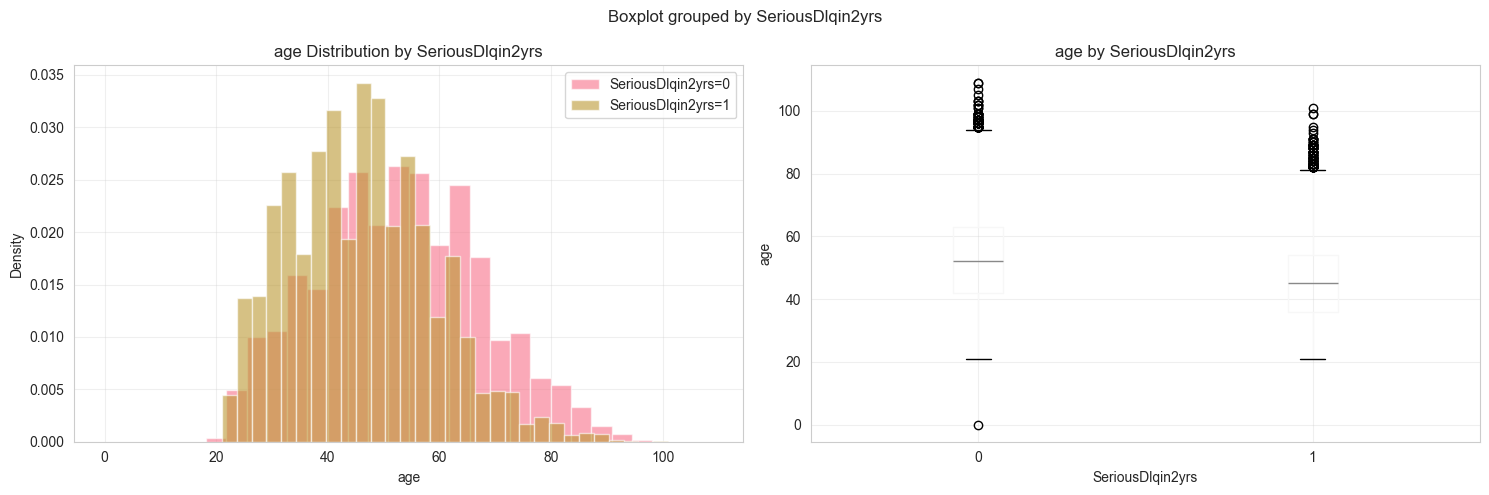

Statistical Test Results for Age:
  Mean age (No Default): 52.75 years
  Mean age (Default):    45.93 years
  P-value:               0.000000
  Significant (p<0.05):  Yes


In [2]:
fig = plot_target_relationship(df, 'age', 'SeriousDlqin2yrs')
fig.savefig(f'{OUTPUT_DIR}/04_age_vs_default.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/04_age_vs_default.png')
plt.show()

test_results = statistical_test(df, 'age', 'SeriousDlqin2yrs')
print(f'Statistical Test Results for Age:')
print(f'  Mean age (No Default): {test_results["mean_class_0"]:.2f} years')
print(f'  Mean age (Default):    {test_results["mean_class_1"]:.2f} years')
print(f'  P-value:               {test_results["p_value_ttest"]:.6f}')
print(f'  Significant (p<0.05):  {"Yes" if test_results["significant_at_0.05"] else "No"}')

## 2. Credit Utilization vs Default

✓ Figure saved: ../outputs/04_credit_utilization_vs_default.png


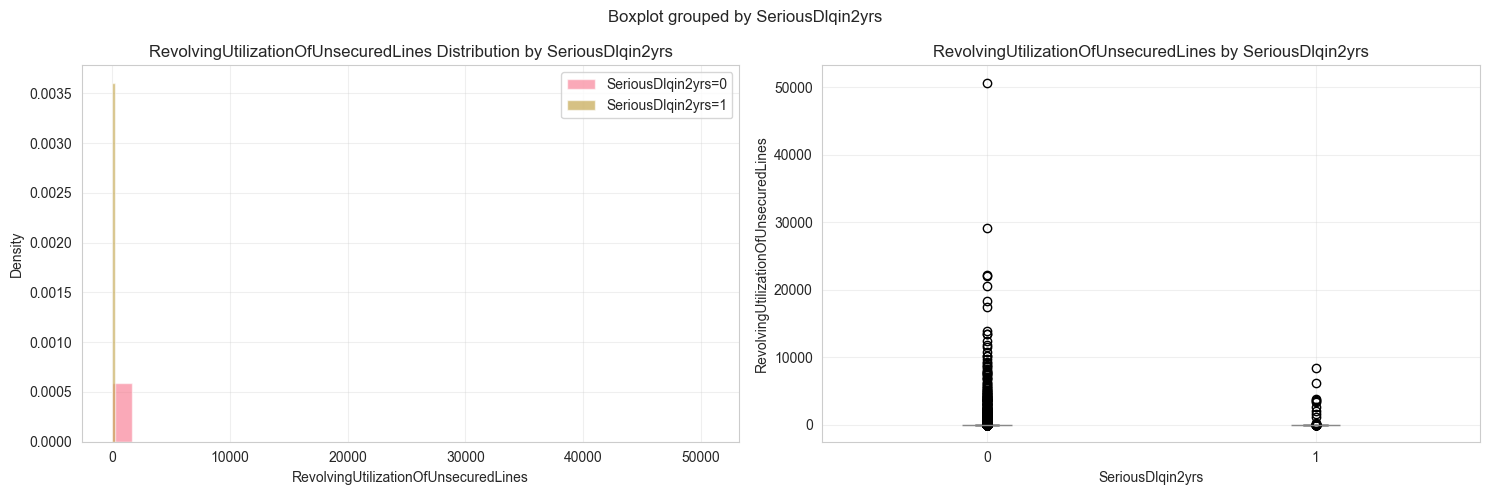

Statistical Test Results for Credit Utilization:
  Mean utilization (No Default): 6.1689
  Mean utilization (Default):    4.3673
  P-value:                       0.485356
  Significant (p<0.05):          No


In [3]:
fig = plot_target_relationship(df, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs')
fig.savefig(f'{OUTPUT_DIR}/04_credit_utilization_vs_default.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/04_credit_utilization_vs_default.png')
plt.show()

test_results = statistical_test(df, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs')
print(f'Statistical Test Results for Credit Utilization:')
print(f'  Mean utilization (No Default): {test_results["mean_class_0"]:.4f}')
print(f'  Mean utilization (Default):    {test_results["mean_class_1"]:.4f}')
print(f'  P-value:                       {test_results["p_value_ttest"]:.6f}')
print(f'  Significant (p<0.05):          {"Yes" if test_results["significant_at_0.05"] else "No"}')

## 3. Debt Ratio vs Default

✓ Figure saved: ../outputs/04_debt_ratio_vs_default.png


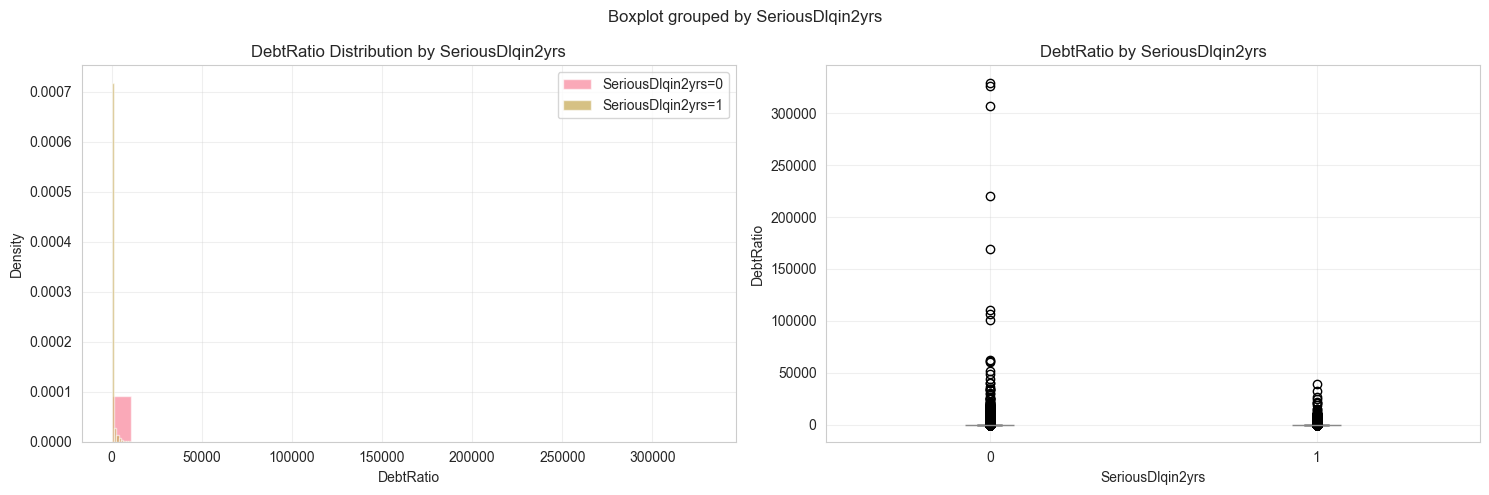

Statistical Test Results for Debt Ratio:
  Mean debt ratio (No Default): 357.1512
  Mean debt ratio (Default):    295.1211
  P-value:                      0.003237
  Significant (p<0.05):         Yes


In [4]:
fig = plot_target_relationship(df, 'DebtRatio', 'SeriousDlqin2yrs')
fig.savefig(f'{OUTPUT_DIR}/04_debt_ratio_vs_default.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/04_debt_ratio_vs_default.png')
plt.show()

test_results = statistical_test(df, 'DebtRatio', 'SeriousDlqin2yrs')
print(f'Statistical Test Results for Debt Ratio:')
print(f'  Mean debt ratio (No Default): {test_results["mean_class_0"]:.4f}')
print(f'  Mean debt ratio (Default):    {test_results["mean_class_1"]:.4f}')
print(f'  P-value:                      {test_results["p_value_ttest"]:.6f}')
print(f'  Significant (p<0.05):         {"Yes" if test_results["significant_at_0.05"] else "No"}')

## 4. Monthly Income vs Default

✓ Figure saved: ../outputs/04_monthly_income_vs_default.png


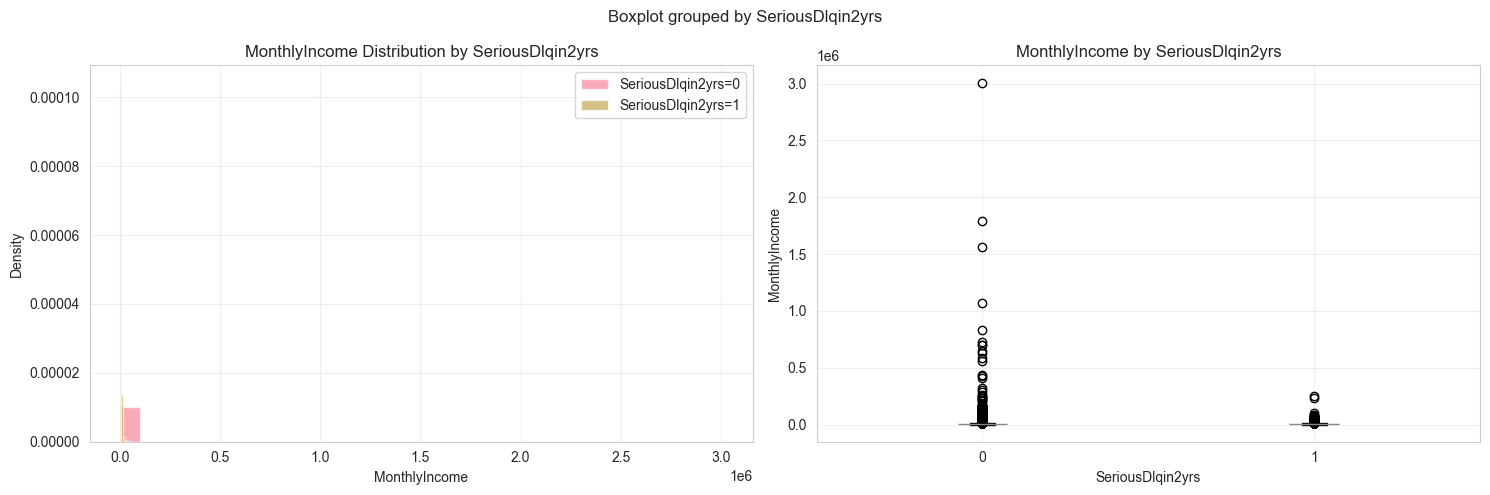

Statistical Test Results for Monthly Income:
  Mean income (No Default): $6,477.62
  Mean income (Default):    $5,592.40
  P-value:                  0.000000
  Significant (p<0.05):     Yes


In [5]:
fig = plot_target_relationship(df, 'MonthlyIncome', 'SeriousDlqin2yrs')
fig.savefig(f'{OUTPUT_DIR}/04_monthly_income_vs_default.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/04_monthly_income_vs_default.png')
plt.show()

test_results = statistical_test(df, 'MonthlyIncome', 'SeriousDlqin2yrs')
print(f'Statistical Test Results for Monthly Income:')
print(f'  Mean income (No Default): ${test_results["mean_class_0"]:,.2f}')
print(f'  Mean income (Default):    ${test_results["mean_class_1"]:,.2f}')
print(f'  P-value:                  {test_results["p_value_ttest"]:.6f}')
print(f'  Significant (p<0.05):     {"Yes" if test_results["significant_at_0.05"] else "No"}')

## 5. Summary: Feature Significance

In [6]:
numerical_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

significance_results = []
for feature in numerical_features:
    try:
        res = statistical_test(df, feature, 'SeriousDlqin2yrs')
        significance_results.append({
            'Feature': feature,
            'Mean_No_Default': round(res['mean_class_0'], 4),
            'Mean_Default': round(res['mean_class_1'], 4),
            'P_Value': round(res['p_value_ttest'], 6),
            'Significant': res['significant_at_0.05']
        })
    except Exception:
        pass

sig_df = pd.DataFrame(significance_results).sort_values('P_Value')
print('Feature Significance Summary (t-test):')
print('=' * 80)
sig_df

Feature Significance Summary (t-test):


,Feature,Mean_No_Default,Mean_Default,P_Value,Significant
1,age,52.7514,45.9266,0.000000,True
2,NumberOfTime30-59DaysPastDueNotWorse,0.2801,2.3885,0.000000,True
5,NumberOfOpenCreditLinesAndLoans,8.4936,7.8823,0.000000,True
4,MonthlyIncome,6477.6231,5592.4015,0.000000,True
6,NumberOfTimes90DaysLate,0.1352,2.0914,0.000000,True
8,NumberOfTime60-89DaysPastDueNotWorse,0.1267,1.8280,0.000000,True
9,NumberOfDependents,0.7235,0.9313,0.000000,True
3,DebtRatio,357.1512,295.1211,0.003237,True
7,NumberRealEstateLoansOrLines,1.0204,0.9885,0.006413,True
0,RevolvingUtilizationOfUnsecuredLines,6.1689,4.3673,0.485356,False


✓ Figure saved: ../outputs/04_feature_target_correlation.png


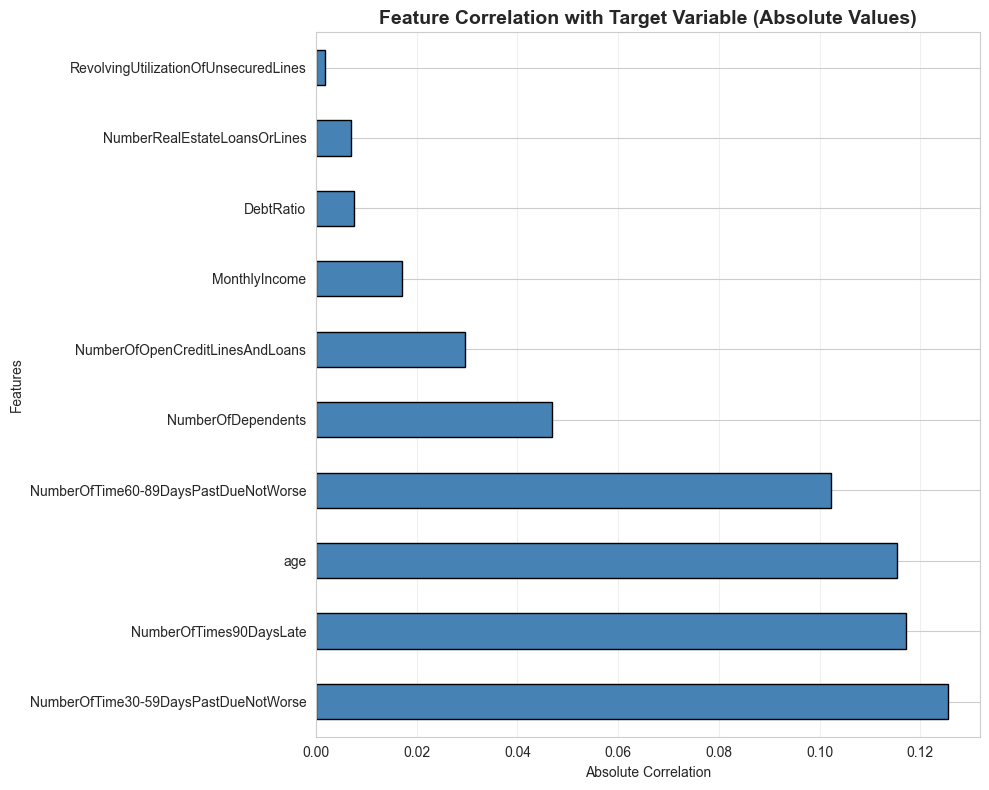


Top 5 Features Correlated with Default:
  NumberOfTime30-59DaysPastDueNotWorse: 0.1256
  NumberOfTimes90DaysLate: 0.1172
  age: -0.1154
  NumberOfTime60-89DaysPastDueNotWorse: 0.1023
  NumberOfDependents: 0.0469

✓ Notebook 04 complete. Figures saved to outputs/


In [7]:
# Correlation with target
target_corr = df[numerical_features + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
target_corr_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Correlation with Target Variable (Absolute Values)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.set_ylabel('Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/04_feature_target_correlation.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/04_feature_target_correlation.png')
plt.show()

print('\nTop 5 Features Correlated with Default:')
print('=' * 60)
for feature, corr_val in target_corr_sorted.head(5).items():
    print(f'  {feature}: {target_corr[feature]:.4f}')

print('\n✓ Notebook 04 complete. Figures saved to outputs/')